<a href="https://colab.research.google.com/github/vaishnavi-saravanan6/agenticAI/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple loggistic regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report

In [ ]:
df=pd.read_csv('simple_loan.csv')
df.head()

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
occupation,0
education_level,0
marital_status,0
income,0
credit_score,0
loan_status,0


In [ ]:
df.duplicated().sum()

np.int64(0)

define features and target

In [ ]:
x=df.drop('loan_status',axis=1)
y=df['loan_status']

In [ ]:
y

,loan_status
0,Approved
1,Approved
2,Denied
3,Approved
4,Approved
...,...
56,Approved
57,Denied
58,Approved
59,Approved


In [ ]:
x

,age,gender,occupation,education_level,marital_status,income,credit_score
0,32,Male,Engineer,Bachelor's,Married,85000,720
1,45,Female,Teacher,Master's,Single,62000,680
2,28,Male,Student,High School,Single,25000,590
3,51,Female,Manager,Bachelor's,Married,105000,780
4,36,Male,Accountant,Bachelor's,Married,75000,710
...,...,...,...,...,...,...,...
56,39,Male,Architect,Master's,Married,100000,770
57,25,Female,Receptionist,High School,Single,32000,570
58,43,Male,Banker,Bachelor's,Married,95000,760
59,30,Female,Writer,Master's,Single,55000,650


In [ ]:
y=y.map({'Approved':1,'Denied':0})

In [ ]:
y

,loan_status
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
56,NaN
57,NaN
58,NaN
59,NaN


In [ ]:
num_cols=x.select_dtypes(include=np.number).columns
cat_cols=x.select_dtypes(include='object').columns


Mapping the target

In [ ]:
y=y.map({'Approved':1,'Denied':0})

In [ ]:
y

,loan_status
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
56,NaN
57,NaN
58,NaN
59,NaN


Encoding the categorical features to numeric value

In [ ]:
encoder=pd.get_dummies(x[cat_cols],drop_first=True)
encoded_x=pd.concat([x[num_cols],encoder],axis=1)

In [ ]:
encoded_cat_df = encoder

In [ ]:
x_final = encoded_x
x_train,x_test,y_train,y_test=train_test_split(x_final,y,test_size=0.2,random_state=42)

In [ ]:
# Re-initialize y from the original DataFrame and apply the correct mapping
y = df['loan_status']
y = y.map({'Approved': 1, 'Denied': 0})

# Re-run the train-test split with the corrected y
x_final = encoded_x # encoded_x is already prepared upstream
x_train,x_test,y_train,y_test=train_test_split(x_final,y,test_size=0.2,random_state=42)

# Now, train the Logistic Regression model
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
acc = (y_test == y_pred).mean()
print(f'Accuracy: {acc:.2f}')

Accuracy: 1.00


In [ ]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[4 0]
 [0 9]]


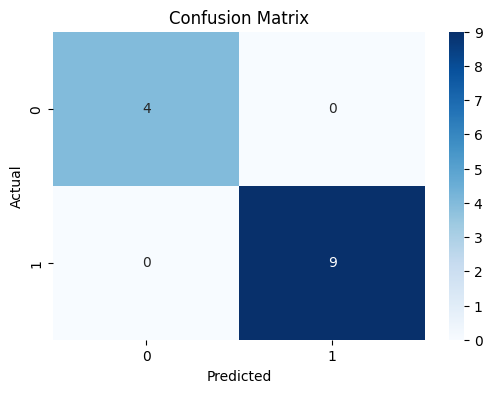

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()